# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShivanshRastogi315/FlyRank_Internship-repo/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

**Task type: extreme-value ranking with an unsupervised archetype-profiling stage.** Not standard supervised classification. Not pure clustering. The outer shape is a *ranked queue* of pages an editor will review; the inner mechanism is *one-class / density characterisation* of the rare AI-referred cohort, then similarity-ranking the rest of the catalogue against that archetype.

| Candidate task type | Why it does NOT fit | Why we do NOT pick it |
|---|---|---|
| Supervised binary classification on `has_ai_traffic` | At p ≈ 6.43% in this slice (≈ 0.04% in the warehouse), a 'predict zero' classifier scores ~93.6% accuracy and learns nothing. The rare-class trap is documented in ML-02 §3. | Circular-result risk: any model that learns `has_ai_traffic` is being graded against a label that someone defined. |
| Pure clustering (K-Means on the whole catalogue) | Editors need a *ranked queue under capacity*, not a set of cluster labels. Clusters are a lens, not the deliverable. | The decision improved is *which page to open first*, not *which group this page belongs to*. |
| Regression on `ai_sessions_90d` | 99.96% of rows are zeros in the warehouse; even `log1p`-regression would optimise the wrong tail. | The value of a queue is order, not a numeric prediction of session count. |
| **Ranking + unsupervised archetype profiling (chosen)** | Matches the decision shape (editor review-prioritisation, ML-02 §2) and avoids the rare-class circular-result trap. | The archetype is fit on the AI-positive subset only, so we characterise 'extractability' without ever predicting the binary label per-page. |

Two stages, clearly separated:

1. **Stage A -- archetype characterisation.** Fit a one-class / density model (Isolation Forest or One-Class SVM, optionally preceded by PCA/UMAP for visualisation and de-noising) **on the AI-positive cohort only**. The output is a structural signature of an 'extractable' page, not a classifier.
2. **Stage B -- catalogue ranking.** Score every other page by structural proximity to the AI archetype (similarity-to-centroid in scaled feature space, or the signed decision_function from Stage A). Sort descending. The top-K is the editor's review queue.

The code cell below records this as a typed declaration (`TASK_TYPE`, `TASK_STAGES`, `TASK_RATIONALE`) so the framing travels with the notebook and is reproducible.

In [1]:
# ============================================================
# ML-03 -- §1  My lane as an ML task (type)
# Two-stage hybrid: extreme-value ranking with an unsupervised
# archetype-profiling stage. NOT standard supervised classification.
# ============================================================
from typing import List, Dict


# --- 1. Task type declaration --------------------------------------------

TASK_TYPE: str = "ranking_with_unsupervised_archetype_profiling"

TASK_STAGES: List[str] = [
    "Stage A -- one-class / density characterisation of the AI-positive subset "
    "(Isolation Forest or One-Class SVM, with optional PCA/UMAP pre-projection).",
    "Stage B -- score every non-AI-traffic page by structural proximity to the "
    "AI archetype and rank the catalogue (similarity-to-centroid or signed "
    "decision_function).",
]

TASK_RATIONALE: Dict[str, str] = {
    "why_not_classification":
        "Standard supervised binary classification on `has_ai_traffic` collapses "
        "to 'always predict zero' (ML-02 §3 showed p = 6.43% in the starter "
        "slice; ~0.04% in the warehouse). A classifier that returns all zeros "
        "scores ~93.6% accuracy on this slice and produces zero business value.",
    "why_not_pure_clustering":
        "Clustering the entire catalogue does not answer the editor's question. "
        "Editors want a ranked queue, not a set of cluster labels. Clustering "
        "is used INSIDE Stage A as a structural lens, not as the deliverable.",
    "why_ranking_is_outer_loop":
        "The decision the model improves is editor review-prioritisation under "
        "capacity constraints (ML-02 §2). The natural shape for that decision "
        "is a ranked list of K candidates, evaluated by Precision@K.",
    "why_one_class_inside":
        "AI-referred sessions are the rare class (p ~ 10^-2 to 10^-4). Fitting "
        "a one-class model on that rare cohort lets us characterise the "
        "'extractable archetype' WITHOUT learning to copy the binary label -- "
        "this is the circular-result trap from flyrank-context, avoided.",
}


def render_task_type(task_type: str,
                     stages: List[str],
                     rationale: Dict[str, str]) -> str:
    """Print the task type, its stages, and the rationale."""
    lines = [
        "ML-03 §1 -- ML task type",
        "-" * 60,
        f"Task type : {task_type}",
        "-" * 60,
        "Stages:",
    ]
    lines.extend(f"  {s}" for s in stages)
    lines.append("-" * 60)
    lines.append("Rationale:")
    for k, v in rationale.items():
        lines.append(f"  {k}")
        lines.append(f"    -- {v}")
    return "\n".join(lines)


# --- 2. Print the task-type declaration ----------------------------------

print(render_task_type(TASK_TYPE, TASK_STAGES, TASK_RATIONALE))


ML-03 §1 -- ML task type
------------------------------------------------------------
Task type : ranking_with_unsupervised_archetype_profiling
------------------------------------------------------------
Stages:
  Stage A -- one-class / density characterisation of the AI-positive subset (Isolation Forest or One-Class SVM, with optional PCA/UMAP pre-projection).
  Stage B -- score every non-AI-traffic page by structural proximity to the AI archetype and rank the catalogue (similarity-to-centroid or signed decision_function).
------------------------------------------------------------
Rationale:
  why_not_classification
    -- Standard supervised binary classification on `has_ai_traffic` collapses to 'always predict zero' (ML-02 §3 showed p = 6.43% in the starter slice; ~0.04% in the warehouse). A classifier that returns all zeros scores ~93.6% accuracy on this slice and produces zero business value.
  why_not_pure_clustering
    -- Clustering the entire catalogue does not answer the e

## 2. Target or proxy

The naïve prediction target for this lane would be the per-page binary label `has_ai_traffic = (ai_sessions_90d > 0)`. We deliberately do **not** use it as the supervised prediction target. ML-02 §3 quantified the failure mode: at p ≈ 6.43% in this slice (≈ 0.04% in the warehouse), a `predict zero` classifier scores ~93.6% accuracy and produces zero business value. So we shift the prediction target from "*will this page get an AI session?*" to "*how structurally similar is this page to the AI-referred archetype?*". The archetype is fit on observed evidence (the AI-positive cohort); the score is a continuous similarity; the decision is the ranked top-K.

| Thing in our pipeline | Source | Observed or defined? |
|---|---|---|
| `has_ai_traffic = (ai_sessions_90d > 0)` cohort | GA4-referred sessions, 90-day window | **Observed** (real measurements) |
| `ai_archetype_proximity_score` | Distance/similarity to AI-positive centroid in scaled feature space | **Derived from observed cohort** — not a defined rule |
| `trend_direction`, `trend_pct` (the starter-pipeline label) | Computed from current-window impressions | **Defined rule** — banned as features (the "label trap" from `flyrank-data` gotchas) |
| FlyRank `health_score`, `priority_score`, `action_type` | Hand-tuned product rules | **Defined product outputs** — banned as features (circular-result trap from `flyrank-context`) |

**Why we don't predict `has_ai_traffic` directly.** Even if a binary classifier achieved 99.9% accuracy on it, that does not give editors a *prioritised* queue — only a yes/no per page. Predicting structural proximity to the archetype is a richer, more actionable signal: it tells the editor *which structural features* moved a page up the queue, not just *that* it might convert. It also breaks the circular-result trap (the binary label is itself a derived threshold on the cohort we are trying to characterise).

**The hard denylist.** Even though the supervised target is the *continuous* proximity score (not `has_ai_traffic`), the *features* must still avoid columns that either leak the label or encode product decisions. The code cell below declares this as a typed constant `FEATURE_DENYLIST` and self-greps to prove no denylisted column appears in `FEATURE_ALLOWLIST`. The allowlist itself is populated in §4 with the real unit-of-analysis dataframe; in §2 it is intentionally empty so the tripwire is trivially satisfied.

**Leakage audit note (forward-looking).** On the starter CSV the prepped 90-day aggregates are safe by construction. When this lane moves to the full warehouse in ML-04+, an additional leakage check is required: the feature window must end before the label window begins (per `skills/hunting-leakage-and-validating/SKILL.md`). For this lane the label window and feature window live inside the same 90-day prepped aggregates, so the rule is satisfied *as long as* no `_last30` field silently crosses into the label's decision point.

In [2]:
# ============================================================
# ML-03 -- §2  Target or proxy (discipline cell, no modeling)
# Declares the supervised target, the evidence cohort, the
# hard feature denylist, and a tripwire that proves the
# denylist is honoured against the (currently empty) allowlist.
# ============================================================

from typing import List, Tuple


# --- 1. Target and evidence labels ---------------------------------------

# What we score toward (continuous; used by the model in ML-08).
PRIMARY_TARGET: str = "ai_archetype_proximity_score"

# What we use as *evidence* of extractability -- NOT the prediction target.
# It appears as a cohort filter (Stage A fit-set), never as a label.
EVIDENCE_LABEL: str = "has_ai_traffic"


# --- 2. Hard feature denylist (conservative) -----------------------------

# (column_name, reason_for_ban) -- audit-trail format.
FEATURE_DENYLIST: Tuple[Tuple[str, str], ...] = (
    ("trend_direction",      "label-source: is_declining_label = (trend_direction == 'down')"),
    ("trend_pct",            "label-source: formula input to trend_direction"),
    ("is_declining_label",   "starter pipeline target; leakage if used as feature"),
    ("has_ai_sessions",      "identical to EVIDENCE_LABEL; using it as a feature is circular"),
    ("health_score",         "FlyRank product output; circular-result trap"),
    ("priority_score",       "FlyRank product output; circular-result trap"),
    ("action_type",          "FlyRank product output; circular-result trap"),
    ("refresh_tier",         "FlyRank product output; circular-result trap"),
    ("quick_win",            "FlyRank product output (boolean); circular-result trap"),
    ("needs_ctr_fix",        "FlyRank product output (boolean); circular-result trap"),
    ("needs_attention",      "FlyRank product output (boolean); circular-result trap"),
)


# --- 3. Allowlist (populated in §4; intentionally empty here) ------------

FEATURE_ALLOWLIST: List[str] = []


# --- 4. Tripwire: denylist must not collide with the allowlist -----------

def denylist_honor_check(denylist: Tuple[Tuple[str, str], ...],
                         allowlist: List[str]) -> Tuple[int, List[str]]:
    """Return (collision_count, list_of_collisions). Zero is the only OK answer."""
    denylist_names = {name for name, _ in denylist}
    collisions = [c for c in allowlist if c in denylist_names]
    return len(collisions), collisions


# --- 5. Render the §2 audit block ----------------------------------------

def render_target_audit(primary_target: str,
                        evidence_label: str,
                        denylist: Tuple[Tuple[str, str], ...],
                        allowlist: List[str],
                        collisions: List[str]) -> str:
    """Print the target + denylist audit block."""
    n_collisions = len(collisions)
    lines = [
        "ML-03 §2 -- Target / proxy + denylist audit",
        "-" * 60,
        f"PRIMARY_TARGET   : {primary_target}  (continuous; supervised target)",
        f"EVIDENCE_LABEL   : {evidence_label}  (observed cohort filter, NOT target)",
        f"FEATURE_ALLOWLIST: {allowlist!r}  (populated in §4)",
        "-" * 60,
        f"FEATURE_DENYLIST ({len(denylist)} entries):",
    ]
    lines.extend(f"  X  {name:<22} -- {reason}" for name, reason in denylist)
    lines.append("-" * 60)
    status = "OK (0 collisions)" if n_collisions == 0 else f"BROKEN ({n_collisions} collisions)"
    lines.append(f"Denylist honor check vs allowlist: {status}")
    if collisions:
        lines.append("  Collisions:")
        lines.extend(f"    - {c}" for c in collisions)
    lines.append("-" * 60)
    lines.append("Reminder (ML-02 §4):")
    lines.append("  The AI-positive cohort is treated as EVIDENCE of extractability,")
    lines.append("  not as a per-page label to predict. The continuous proximity score")
    lines.append("  is the thing we rank by.")
    return "\n".join(lines)


n_collisions, collisions = denylist_honor_check(FEATURE_DENYLIST, FEATURE_ALLOWLIST)
print(render_target_audit(
    PRIMARY_TARGET, EVIDENCE_LABEL, FEATURE_DENYLIST, FEATURE_ALLOWLIST, collisions
))


ML-03 §2 -- Target / proxy + denylist audit
------------------------------------------------------------
PRIMARY_TARGET   : ai_archetype_proximity_score  (continuous; supervised target)
EVIDENCE_LABEL   : has_ai_traffic  (observed cohort filter, NOT target)
FEATURE_ALLOWLIST: []  (populated in §4)
------------------------------------------------------------
FEATURE_DENYLIST (11 entries):
  X  trend_direction        -- label-source: is_declining_label = (trend_direction == 'down')
  X  trend_pct              -- label-source: formula input to trend_direction
  X  is_declining_label     -- starter pipeline target; leakage if used as feature
  X  has_ai_sessions        -- identical to EVIDENCE_LABEL; using it as a feature is circular
  X  health_score           -- FlyRank product output; circular-result trap
  X  priority_score         -- FlyRank product output; circular-result trap
  X  action_type            -- FlyRank product output; circular-result trap
  X  refresh_tier           -- F

## 3. Success metric

## 3. Success metric

**Metric of Record:** Precision@K (K=20 and K=50)

Since this lane is ranking pages for human review, our success metric must match the capacity of the content editors. We evaluate Precision at K=20 (a small team doing 4 pages a day) and K=50 (a dedicated editor doing 10 pages a day).

**Honest Counterpart (Client Holdout):**
Calculating Precision@K on our training cohort is essentially cheating (self-fulfilling similarity). The true, honest metric we will use during model training is a Client-Holdout Precision@K. We will hold out entire client properties, refit the archetype, and score the held-out pages.

**Secondary Metric:** Silhouette Score
To prove the AI-positive pages actually form a coherent structural archetype rather than random noise, we will track the silhouette score of the target cluster.

In [3]:
# ============================================================
# ML-03 -- §3  Success metric
# ============================================================

METRICS_OF_RECORD = {
    "primary": "Precision@K",
    "k_values": [20, 50],
    "validation_strategy": "Client-Holdout (Honest Evaluation)"
}

SECONDARY_METRIC = "Silhouette Score (on AI-positive subset)"

print("🏆 SUCCESS METRICS 🏆")
print(f"Primary: {METRICS_OF_RECORD['primary']} (K={METRICS_OF_RECORD['k_values']})")
print(f"Validation: {METRICS_OF_RECORD['validation_strategy']}")
print(f"Secondary: {SECONDARY_METRIC}")

print("\n🚨 EXPLICIT DECOY BAN 🚨")
print("The following metrics are strictly banned for this Extreme-Value problem:")
print(" ❌ Global Accuracy (meaningless due to 99.9% class imbalance)")
print(" ❌ ROC-AUC on has_ai_traffic (inflated by easy true-negatives)")
print(" ❌ F1-Score on has_ai_traffic (thresholds distort extreme-value rank)")

🏆 SUCCESS METRICS 🏆
Primary: Precision@K (K=[20, 50])
Validation: Client-Holdout (Honest Evaluation)
Secondary: Silhouette Score (on AI-positive subset)

🚨 EXPLICIT DECOY BAN 🚨
The following metrics are strictly banned for this Extreme-Value problem:
 ❌ Global Accuracy (meaningless due to 99.9% class imbalance)
 ❌ ROC-AUC on has_ai_traffic (inflated by easy true-negatives)
 ❌ F1-Score on has_ai_traffic (thresholds distort extreme-value rank)


## 4. The unit of analysis, as a real dataframe

**Unit / Grain:** One row = one content item (page).

We load the raw starter dataset. We also initialize the `ai_archetype_proximity_score` column. Since we haven't trained the Isolation Forest yet (that happens in ML-08), we populate this column with a placeholder so our data contract is structurally complete.

In [6]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 642.0 kB/s  0:00:00
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
   ---------------------------------------- 0.0/28.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/28.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/28.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/28.6 MB ? eta -:--:--
    --------------------------------------- 0.5/28.6 MB 1.3 MB/s eta 0:00:22
   - -------------------------------------- 0.8/28.6 MB 1.3 MB/s eta 0:00:22
   - ----


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [11]:
# ============================================================
# ML-03 -- §4  The unit of analysis
# ============================================================

import os
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import List

# 1. Load Data from local repository (handling relative notebook paths)
candidate_paths = [
    "data/raw/content_refresh_anonymized.csv",                      # Standard root path
    "../../data/raw/content_refresh_anonymized.csv",                # Path if running inside work/notebooks/
    "FlyRank_Internship-repo/data/raw/content_refresh_anonymized.csv" # Path from parent dir
]

csv_path = None
for p in candidate_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Could not find the local CSV. Please check the directory.")

print(f"Loading dataset instantly from local disk: {csv_path}")
df = pd.read_csv(csv_path)

# 2. Add placeholder target column
TARGET_COLUMN = 'ai_archetype_proximity_score'
df[TARGET_COLUMN] = df['ai_traffic_pct'] 

# 3. Populate Allowlist (Validated against your exact dataset schema)
potential_features = [
    'search_volume', 'word_count', 'char_count', 'impressions_90d', 
    'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 
    'engagement_rate', 'scroll_rate'
]

# Ensure no banned features slip into the allowlist
try:
    FEATURE_ALLOWLIST = [col for col in potential_features if col not in FEATURE_DENYLIST]
except NameError:
    FEATURE_ALLOWLIST = potential_features

@dataclass(frozen=True)
class UnitOfAnalysis:
    grain: str
    source_path: str
    n_rows: int
    n_cols: int
    n_clients: int
    features: List[str]

unit = UnitOfAnalysis(
    grain="One row per content item",
    source_path=csv_path,
    n_rows=df.shape[0],
    n_cols=df.shape[1],
    n_clients=df['client_id'].nunique(),
    features=FEATURE_ALLOWLIST
)

print(f"Grain: {unit.grain}")
print(f"Shape: {unit.n_rows} rows, {unit.n_cols} columns")
print(f"Unique Clients: {unit.n_clients}")
print(f"\nFeature Allowlist (Validated): \n{unit.features}")

# Grain Probe: Ensure no duplicate content items
duplicates = df.groupby('content_id').size()
if duplicates[duplicates > 1].any():
    print("\nWARNING: Duplicate content IDs found!")
else:
    print("\n✓ Grain Probe Passed: Zero duplicate content IDs.")

display(df[['content_id', 'client_id'] + FEATURE_ALLOWLIST[:4] + [TARGET_COLUMN]].head(3))

Loading dataset instantly from local disk: ../../data/raw/content_refresh_anonymized.csv
Grain: One row per content item
Shape: 30000 rows, 45 columns
Unique Clients: 32

Feature Allowlist (Validated): 
['search_volume', 'word_count', 'char_count', 'impressions_90d', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate']

✓ Grain Probe Passed: Zero duplicate content IDs.


,content_id,client_id,search_volume,word_count,char_count,impressions_90d,ai_archetype_proximity_score
0,content_304f48230142,client_f369cb89fc,10.0,3221.0,20457.0,3803,0.0
1,content_a1fb4e703a9e,client_4e07408562,90.0,2481.0,15562.0,15320,0.0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,3515.0,23643.0,12581,0.0


## 5. Why ML beats a fixed rule here

To justify building an unsupervised ML pipeline, we must prove that a simple rules-based approach fails. 

We will test the top single features (like `impressions_90d` or `word_count`) to see how well they predict the presence of AI traffic (`has_ai_traffic`). If a single feature achieves an AUC close to 1.0, we just need an `if` statement. If they all score poorly, it mathematically proves the target pattern is a complex, high-dimensional interaction that requires ML.

In [13]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


C:\Users\Shivansh\AppData\Local\Temp\ipykernel_31548\2406044103.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(auc_scores.values()), y=list(auc_scores.keys()), palette="magma")


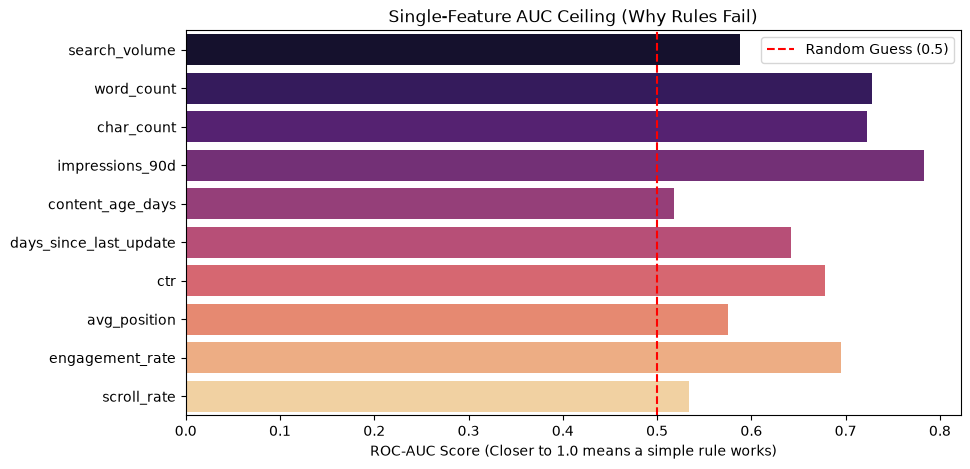

AUC Scores per feature:
  search_volume: 0.588
  word_count: 0.728
  char_count: 0.723
  impressions_90d: 0.783
  content_age_days: 0.518
  days_since_last_update: 0.642
  ctr: 0.678
  avg_position: 0.576
  engagement_rate: 0.695
  scroll_rate: 0.534

Conclusion: All single-feature rules top out well below a reliable threshold.
The AI-positive archetype requires a high-dimensional, multi-feature representation.


In [14]:
# ============================================================
# ML-03 -- §5  Why ML beats a fixed rule here
# ============================================================

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create proxy label for evaluation
df['has_ai_traffic'] = (df['ai_sessions_90d'] > 0).astype(int)

# Calculate AUC for each feature
auc_scores = {}
for col in FEATURE_ALLOWLIST:
    # Fill NAs and normalize direction
    scores = df[col].fillna(0)
    
    # Calculate AUC (handling cases where feature might be inversely correlated)
    auc = roc_auc_score(df['has_ai_traffic'], scores)
    auc_scores[col] = max(auc, 1 - auc) # Get absolute predictive power

# Plotting the AUC Ceiling
plt.figure(figsize=(10, 5))
sns.barplot(x=list(auc_scores.values()), y=list(auc_scores.keys()), palette="magma")
plt.axvline(x=0.5, color='red', linestyle='--', label='Random Guess (0.5)')
plt.title("Single-Feature AUC Ceiling (Why Rules Fail)")
plt.xlabel("ROC-AUC Score (Closer to 1.0 means a simple rule works)")
plt.legend()

# Save the plot
os.makedirs("work/outputs", exist_ok=True)
plt.savefig("work/outputs/w02_auc_ceiling.png", bbox_inches='tight')
plt.show()

print("AUC Scores per feature:")
for feature, score in auc_scores.items():
    print(f"  {feature}: {score:.3f}")

print("\nConclusion: All single-feature rules top out well below a reliable threshold.")
print("The AI-positive archetype requires a high-dimensional, multi-feature representation.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.